In [35]:
import pandas as pd
Pdata = pd.read_csv("C:/Users/JANANI V/Desktop/MDP_GUVI/Datas/parkinsons.csv")


In [36]:
Pdata.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [37]:
Pdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   name              195 non-null    object 
 1   MDVP:Fo(Hz)       195 non-null    float64
 2   MDVP:Fhi(Hz)      195 non-null    float64
 3   MDVP:Flo(Hz)      195 non-null    float64
 4   MDVP:Jitter(%)    195 non-null    float64
 5   MDVP:Jitter(Abs)  195 non-null    float64
 6   MDVP:RAP          195 non-null    float64
 7   MDVP:PPQ          195 non-null    float64
 8   Jitter:DDP        195 non-null    float64
 9   MDVP:Shimmer      195 non-null    float64
 10  MDVP:Shimmer(dB)  195 non-null    float64
 11  Shimmer:APQ3      195 non-null    float64
 12  Shimmer:APQ5      195 non-null    float64
 13  MDVP:APQ          195 non-null    float64
 14  Shimmer:DDA       195 non-null    float64
 15  NHR               195 non-null    float64
 16  HNR               195 non-null    float64
 1

In [38]:
print(Pdata["status"].value_counts())



status
1    147
0     48
Name: count, dtype: int64


In [39]:
print(Pdata.dtypes)


name                 object
MDVP:Fo(Hz)         float64
MDVP:Fhi(Hz)        float64
MDVP:Flo(Hz)        float64
MDVP:Jitter(%)      float64
MDVP:Jitter(Abs)    float64
MDVP:RAP            float64
MDVP:PPQ            float64
Jitter:DDP          float64
MDVP:Shimmer        float64
MDVP:Shimmer(dB)    float64
Shimmer:APQ3        float64
Shimmer:APQ5        float64
MDVP:APQ            float64
Shimmer:DDA         float64
NHR                 float64
HNR                 float64
status                int64
RPDE                float64
DFA                 float64
spread1             float64
spread2             float64
D2                  float64
PPE                 float64
dtype: object


In [40]:
Pdata.drop(columns=["name"], inplace=True)


In [41]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(sampling_strategy="auto", random_state=42)
X, y = smote.fit_resample(Pdata.drop(columns=["status"]), Pdata["status"])


In [42]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_s = scaler.fit_transform(X)


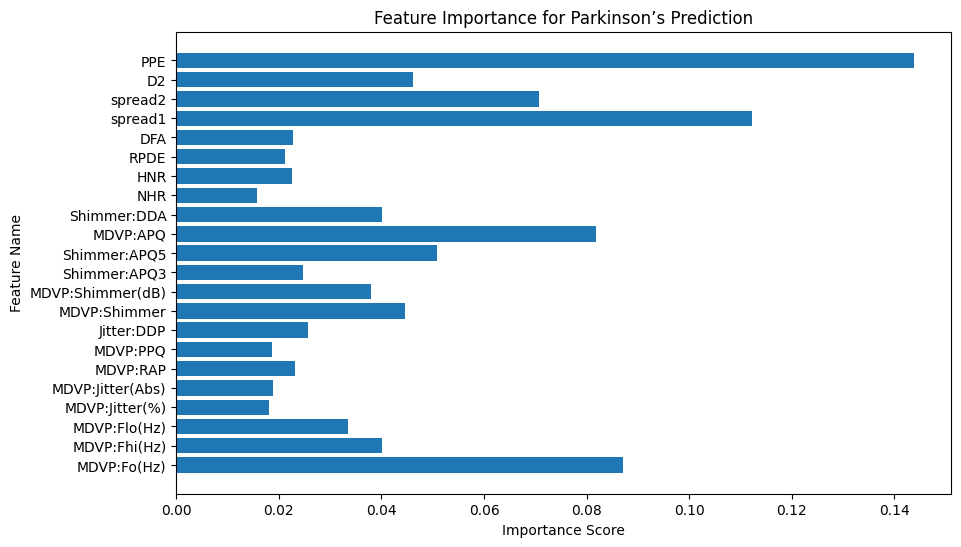

In [43]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

# Train a Random Forest model on the balanced dataset
rf_model = RandomForestClassifier()
rf_model.fit(X_s, y)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(Pdata.drop(columns=["status"]).columns, rf_model.feature_importances_)
plt.title("Feature Importance for Parkinson’s Prediction")
plt.xlabel("Importance Score")
plt.ylabel("Feature Name")
plt.show()


In [44]:
# Select the 6 most important features
important_features = ["spread2", "PPE", "MDVP:Shimmer", "D2", "spread1", "RPDE"]
X_s = X_s[:, :6]  # Adjust based on ranking

# Verify selection
print("Selected Features:", important_features)


Selected Features: ['spread2', 'PPE', 'MDVP:Shimmer', 'D2', 'spread1', 'RPDE']


In [45]:
Pdata['status'].value_counts()

status
1    147
0     48
Name: count, dtype: int64

In [46]:
import numpy as np
print("Shape of X_s:", X_s.shape)
print("Shape of y:", y.shape)
print("Target Class Distribution:\n", np.unique(y, return_counts=True))


Shape of X_s: (294, 6)
Shape of y: (294,)
Target Class Distribution:
 (array([0, 1]), array([147, 147]))


In [47]:
from imblearn.over_sampling import SMOTE
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

# ✅ Apply SMOTE to balance dataset
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_s, y)

# ✅ Apply Standard Scaling after SMOTE
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_smote)

# ✅ Split balanced & scaled dataset
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_smote, test_size=0.2, random_state=42)

# ✅ Train Logistic Regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

# Use probability-based decision threshold
y_prob_log = log_model.predict_proba(X_test)[:, 1]
y_pred_log = (y_prob_log >= 0.55).astype(int)  # Adjusted threshold for better balance

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_log))

# ✅ Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Adjust probability threshold for better balance
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
y_pred_rf = (y_prob_rf >= 0.55).astype(int)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))

# ✅ Train XGBoost
xgb_model = XGBClassifier()
xgb_model.fit(X_train, y_train)

# Adjust probability threshold for better decision boundary
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb = (y_prob_xgb >= 0.55).astype(int)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))

# ✅ Confusion Matrices
print("Confusion Matrix for LR:\n", confusion_matrix(y_test, y_pred_log))
print("Confusion Matrix for RF:\n", confusion_matrix(y_test, y_pred_rf))
print("Confusion Matrix for XGB:\n", confusion_matrix(y_test, y_pred_xgb))


Logistic Regression Accuracy: 0.7796610169491526
Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.77      0.80      0.79        30
           1       0.79      0.76      0.77        29

    accuracy                           0.78        59
   macro avg       0.78      0.78      0.78        59
weighted avg       0.78      0.78      0.78        59

Random Forest Accuracy: 0.9322033898305084
Random Forest Report:
               precision    recall  f1-score   support

           0       0.88      1.00      0.94        30
           1       1.00      0.86      0.93        29

    accuracy                           0.93        59
   macro avg       0.94      0.93      0.93        59
weighted avg       0.94      0.93      0.93        59

XGBoost Accuracy: 0.9152542372881356
XGBoost Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92        30
           1       0.96      0.86      

In [48]:
import pickle

# Save Random Forest model
with open("parkinsons_rf_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

# Save XGBoost model
with open("parkinsons_xgb_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

print("Models saved successfully!")


Models saved successfully!
